# Алгоритмы

Обычно алгоритмы оценивают по:
- памяти
- времени

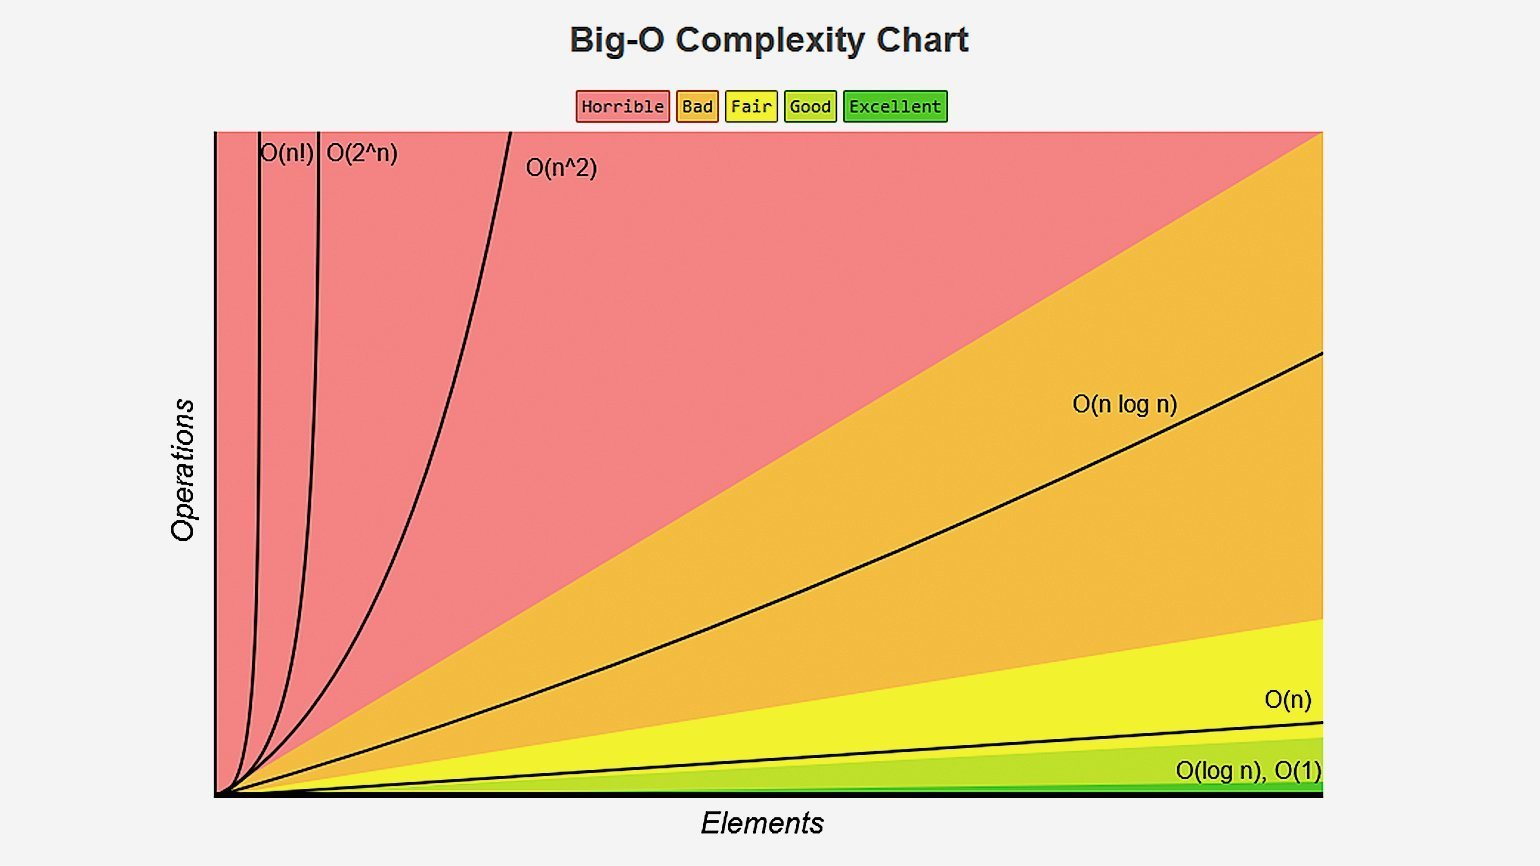

## Оценка по памяти

Оценка по памяти заключается в ответе на вопрос, сколько нужно будет выделить памяти для решения задачи (n -> inf)

Попробуем сделать функцию, что нам удалит из исходного массива нечетные числа

In [1]:
def bad_clear(data):
  new_data = []
  for item in data:
    if item % 2 == 0:
      new_data.append(item)
  return new_data

In [2]:
bad_clear([1,4,5,2,3,1,7,8])

[4, 2, 8]

In [ ]:
# 1 4 5 2 3    i = 0 j = 4
# 3 4 5 2 1    i = 0 j = 3
# 2 4 5 3 1    i = 1 j = 2
# 2 4 5 3 1    i = 2 j = 2
# [0:2]

А можно ли потратить меньше памяти?

In [3]:
def good_clear(data):
  i = 0
  j = len(data)

  while i < j:
    if data[i] % 2 == 0:
      i += 1
    else:
      data[i], data[j-1] = data[j-1], data[i]
      j -= 1

  return data[:j]

In [4]:
data_1 = [2,4,6,8,10,12]
print(bad_clear(data_1))
print(good_clear(data_1))

[2, 4, 6, 8, 10, 12]
[2, 4, 6, 8, 10, 12]


In [5]:
data_2 = [1,5,2,4,9,10,2,8,1]
print(bad_clear(data_2))
print(good_clear(data_2))

[2, 4, 10, 2, 8]
[8, 2, 2, 4, 10]


In [6]:
data_3 = [1,5,7,11,5,7,21]
print(bad_clear(data_3))
print(good_clear(data_3))

[]
[]


## Оценка по времени

Оценка по времени заключается в ответе на вопрос, сколько времени займет решение проблемы (n -> inf)

Попробуем, к примеру, отсортировать массив

In [7]:
def bubble_sort(data):
  for i in range(len(data)):
    for j in range(len(data)-i-1):
      if data[j] > data[j+1]:
        data[j], data[j+1] = data[j+1], data[j]

![image.png](https://upload.wikimedia.org/wikipedia/commons/c/c8/Bubble-sort-example-300px.gif)

In [8]:
data = [1,3,67,21,3,45,1]
bubble_sort(data)
print(data)

[1, 1, 3, 3, 21, 45, 67]


Выходит, что сложность - O(n^2); можно ли быстрее?

In [9]:
def radix_sort(data):
  colours = {"red": 0, "orange": 0, "yellow": 0, "green": 0, "light-blue": 0, "blue": 0, "purple": 0}

  for item in data:
    colours[item] += 1

  res = []
  for k, v in colours.items():
    for i in range(v):
      res.append(k)

  return res

In [10]:
data = ["red", "blue", "blue", "yellow", "green"]
print(radix_sort(data))

['red', 'yellow', 'green', 'blue', 'blue']


https://www.youtube.com/watch?v=BeoCbJPuvSE

https://leetcode.com/problemset/all/?sorting=W3sic29ydE9yZGVyIjoiQVNDRU5ESU5HIiwib3JkZXJCeSI6IkRJRkZJQ1VMVFkifV0%3D

https://www.codewars.com/

Неплохой способ определить сложность - построить графики

In [14]:
def selection_sort(arr): # O(n^2)
    for i in range(len(arr)):
        minimum = i
        for j in range(i + 1, len(arr)):
            if arr[j] < arr[minimum]:
                minimum = j
        arr[minimum], arr[i] = arr[i], arr[minimum]

    return arr

![image.png](https://pythonru.com/wp-content/uploads/2020/05/sortirovka-vyborom-na-python.gif)

In [15]:
def insertion_sort(arr):  # O(n^2)
    for i in range(len(arr)):
        cursor = arr[i]
        pos = i
        while pos > 0 and arr[pos - 1] > cursor:
            arr[pos] = arr[pos - 1]
            pos = pos - 1
        arr[pos] = cursor
    return arr

![image.png](https://pythonru.com/wp-content/uploads/2020/05/sortirovka-vstavkami-na-python.gif)

In [11]:
def partition(array, begin, end):
    pivot_idx = begin
    for i in range(begin+1, end+1):
        if array[i] <= array[begin]:
            pivot_idx += 1
            array[i], array[pivot_idx] = array[pivot_idx], array[i]
    array[pivot_idx], array[begin] = array[begin], array[pivot_idx]
    return pivot_idx

def quick_sort_recursion(array, begin, end):
    if begin >= end:
        return
    pivot_idx = partition(array, begin, end)
    quick_sort_recursion(array, begin, pivot_idx-1)
    quick_sort_recursion(array, pivot_idx+1, end)

def quick_sort(array, begin=0, end=None):  # O(n * log n)
    if end is None:
        end = len(array) - 1

    return quick_sort_recursion(array, begin, end)

![image.png](https://pythonru.com/wp-content/uploads/2020/05/bystraya-sortirovka-na-python.gif)

In [12]:
import random
import time
import matplotlib.pyplot as plt

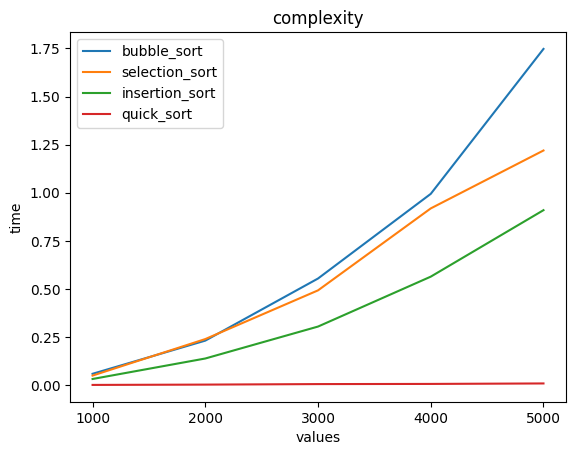

In [16]:
nn = range(1000,6000,1000)
algs = [bubble_sort, selection_sort, insertion_sort, quick_sort]

results = []
for alg in algs:
  alg_res = []
  for n in nn:
    data = [ random.randint(1,10000) for i in range(n) ]
    start = time.time()
    alg(data)
    end = time.time() - start
    alg_res.append(end)
  results.append(alg_res)

for i in range(len(algs)):
  plt.plot(nn, results[i], label=algs[i].__name__)

plt.legend()
plt.xlabel('values')
plt.xticks(nn)
plt.ylabel('time')
plt.title('complexity')
plt.show()

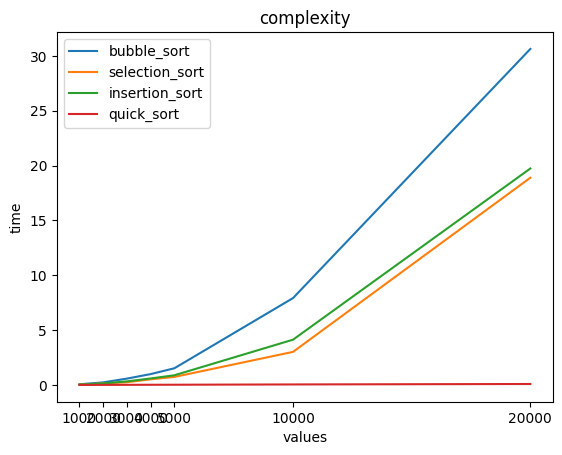

In [17]:
nn = list(range(1000,6000,1000)) + [10000, 20000]
algs = [bubble_sort, selection_sort, insertion_sort, quick_sort]

results = []
for alg in algs:
  alg_res = []
  for n in nn:
    # if n >= 10000 and alg.__name__ != 'quick_sort':
    #   continue
    data = [ random.randint(1,10000) for i in range(n) ]
    start = time.time()
    alg(data)
    end = time.time() - start
    alg_res.append(end)
  results.append(alg_res)

for i in range(len(algs)):
  # if algs[i].__name__ == 'quick_sort':
  plt.plot(nn, results[i], label=algs[i].__name__)
  # else:
    # plt.plot(nn[:len(nn)-2], results[i], label=algs[i].__name__)

plt.legend()
plt.xlabel('values')
plt.xticks(nn)
plt.ylabel('time')
plt.title('complexity')
plt.show()

# Структуры

Структуры - объекты, хранящие в себе однотипные данные. Рассмотрим некоторые из них.

## Словари

In [18]:
hash("testtest")

6163442269746598194

In [20]:
hash("testtestA")

2427892004139399862

In [ ]:
a = [("a", 1), ("v", 2)]

In [21]:
class HashTable:
  def __init__(self, size=10):
    self.__size = size
    self.__table = [None for _ in range(size)]

  def __hash_function(self, key):
    return hash(key) % self.__size

  def all_vals(self):
    print(self.__table)

  def insert(self, key, value):
    index = self.__hash_function(key)
    self.__table[index] = value

  def search(self, key):
    index = self.__hash_function(key)
    return self.__table[index]

  def delete(self, key):
    index = self.__hash_function(key)
    if self.__table[index]:
      self.__table[index] = None
      return
    print("Key not found")

In [22]:
t = HashTable()
t.all_vals()

[None, None, None, None, None, None, None, None, None, None]


In [23]:
t.insert("a", 1)
print(t.search("a"))
print(t.search("b"))
t.all_vals()

1
None
[None, None, None, None, None, None, 1, None, None, None]


In [25]:
t.insert("b", 2)
print(t.search("b"))
t.all_vals()

2
[None, None, None, None, None, 2, 1, None, None, None]


In [26]:
t.delete("b")
print(t.search("b"))
t.delete("b")
print(t.search("b"))

None
Key not found
None


Что будет, если у нескольких ключей будет одинаковый хэш?

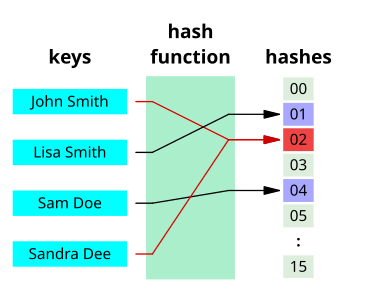

In [27]:
def find_collision(key, size):
  target = hash(key) % size

  for i in "abcdefghijklmnopqrstuvwxyz":
    new = hash(i) % 10
    if new == target and i != key:
      return i

  return None

In [28]:
t.all_vals()

[None, None, None, None, None, None, 1, None, None, None]


In [29]:
c = find_collision("a", 10)
print(c)

s


In [30]:
t.insert(c, 10)
t.all_vals()

[None, None, None, None, None, None, 10, None, None, None]


Есть разные варианты борьбы

Separate chaining:

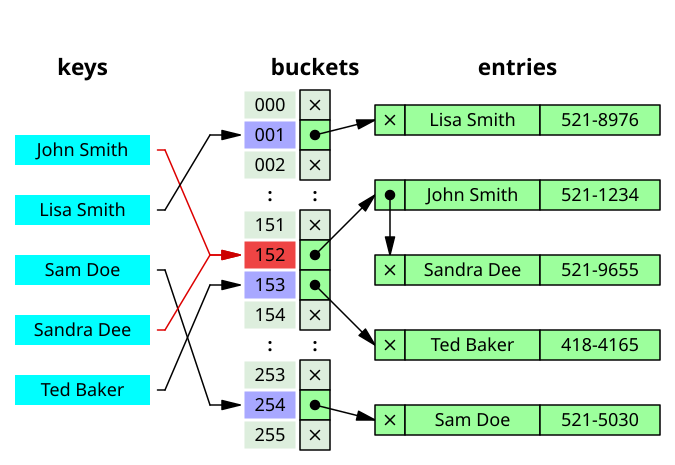

In [31]:
class HashTable:
  def __init__(self, size=10):
    self.__size = size
    self.__table = [[] for _ in range(size)]

  def __hash_function(self, key):
    return hash(key) % self.__size

  def all_vals(self):
    print(self.__table)

  def insert(self, key, value):
    index = self.__hash_function(key)
    for pair in self.__table[index]:
      if pair[0] == key:
        pair[1] = value
        return
    self.__table[index].append([key, value])

  def search(self, key):
    index = self.__hash_function(key)
    for pair in self.__table[index]:
      if pair[0] == key:
        return pair[1]
    return None

  def delete(self, key):
    index = self.__hash_function(key)
    for i, pair in enumerate(self.__table[index]):
      if pair[0] == key:
        del self.__table[index][i]
        return
    print("Key not found")

In [32]:
t = HashTable()
t.insert("a", 1)
print(t.search("a"))
print(t.search("b"))

1
None


In [33]:
t.insert("b", 2)
print(t.search("b"))

2


In [34]:
t.delete("b")
print(t.search("b"))
t.delete("b")
print(t.search("b"))

None
Key not found
None


In [35]:
t.all_vals()
t.insert(c, 10)
t.all_vals()

[[], [], [], [], [], [], [['a', 1]], [], [], []]
[[], [], [], [], [], [], [['a', 1], ['s', 10]], [], [], []]


Open addressing:

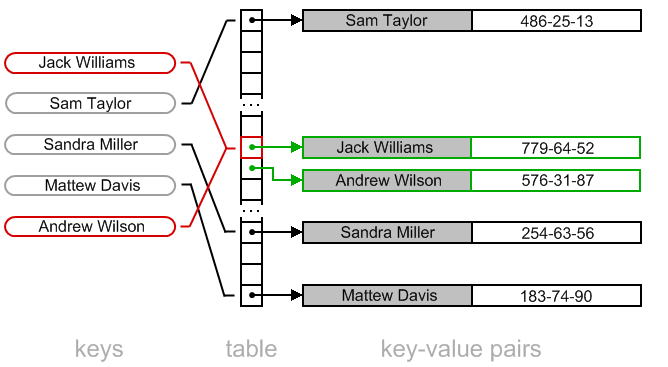

In [36]:
class HashTable:
  def __init__(self, size=10):
    self.__size = size
    self.__table = [None for _ in range(size)]

  def __hash_function(self, key):
    return hash(key) % self.__size

  def all_vals(self):
    print(self.__table)

  def insert(self, key, value):
    index = self.__hash_function(key)

    slot = index
    while self.__table[slot]:
      slot += 1

    self.__table[slot] = (key, value)

  def search(self, key):
    index = self.__hash_function(key)

    slot = index
    while slot < len(self.__table):
      res = self.__table[slot]
      if res:
        k, v = res
        if k == key:
          return v
      slot += 1

    return None

  def delete(self, key):
    index = self.__hash_function(key)

    slot = index
    while slot < len(self.__table):
      res = self.__table[slot]
      if res:
        k, v = res
        if k == key:
          self.__table[slot] = None
          return
      slot += 1
    print("Key not found")

In [37]:
t = HashTable()
t.insert("a", 1)
print(t.search("a"))
print(t.search("b"))

1
None


In [38]:
t.insert("b", 2)
print(t.search("b"))

2


In [39]:
t.delete("b")
print(t.search("b"))
t.delete("b")
print(t.search("b"))

None
Key not found
None


In [40]:
t.all_vals()
t.insert(c, 10)
t.all_vals()

[None, None, None, None, None, None, ('a', 1), None, None, None]
[None, None, None, None, None, None, ('a', 1), ('s', 10), None, None]


А зачем вообще нужно хэширование?

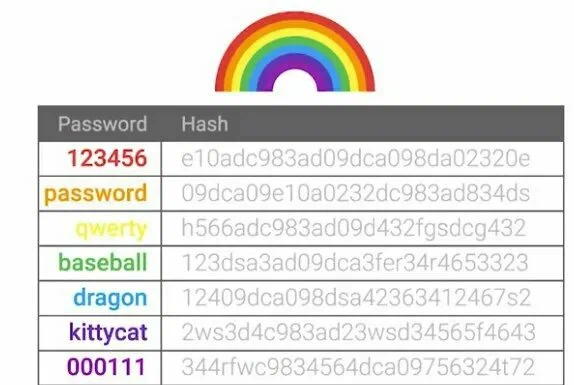

1) login, password
2) login, hash(password)
3) login, hash(hash(password) + salt)

## Очереди (FIFO)

In [41]:
class Queue():
  def __init__(self):
    self.values = []

  def put(self, value):
    self.values.append(value)

  def pop(self):
    print(self.values[0])
    self.values = self.values[1:]

In [42]:
q = Queue()
q.put(3)
q.put(5)
q.put(7)
q.pop()
q.pop()
q.pop()

3
5
7


In [44]:
# store   queue    handler
#  []
#  [1]
#  []       1
#  [2]               1
#  []       2        1
#  [3]      2        1
#  []      3 2       1
#  [4]     3 2
#  []      4 3       2

Где же используются очереди?

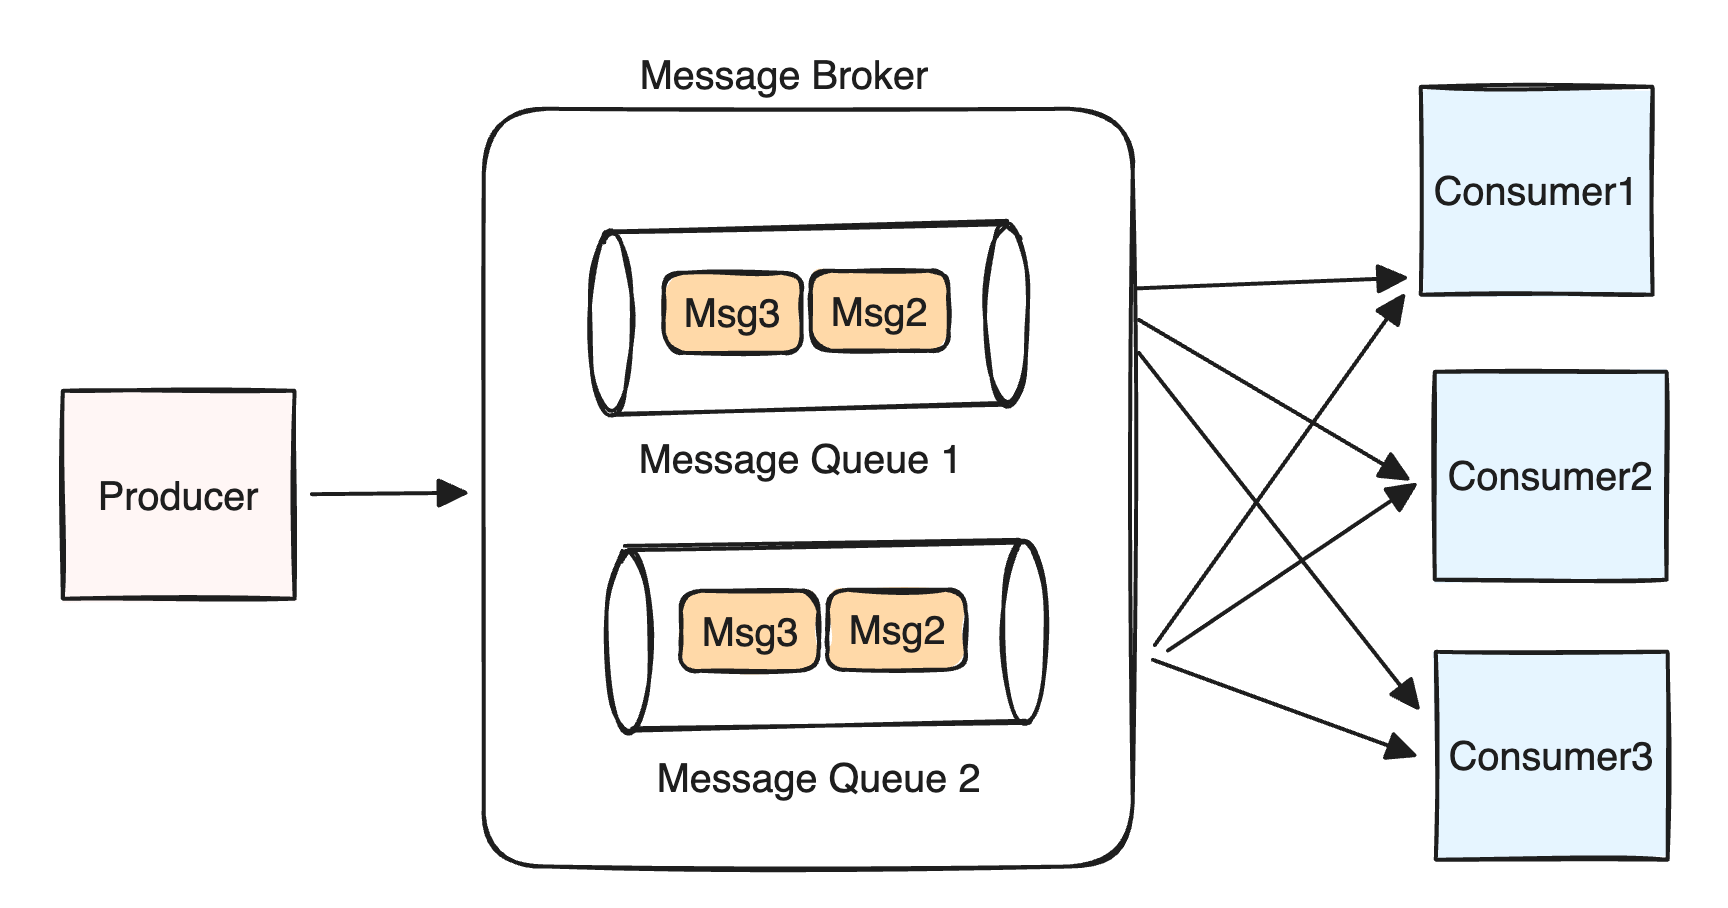

## Стеки (LIFO)

In [46]:
class Stack():
  def __init__(self):
    self.values = []

  def put(self, value):
    self.values.append(value)

  def pop(self):
    print(self.values[len(self.values)-1])
    self.values = self.values[:len(self.values)-1]

In [47]:
s = Stack()
s.put(3)
s.put(5)
s.put(7)
s.pop()
s.pop()
s.pop()

7
5
3


Где мы можем встретить стек?

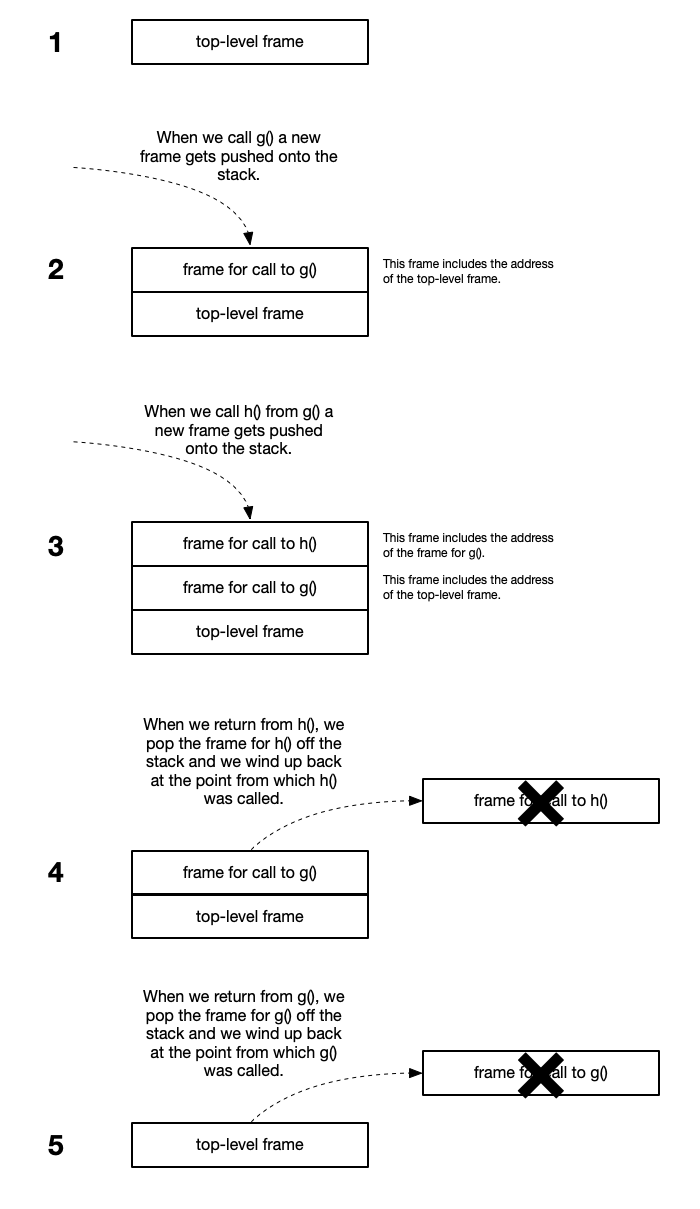

In [48]:
import inspect

In [49]:
EXCLUSIONS = ('EXCLUSIONS', 'TAB', 'filter_vars',
              'pretty_code', 'pretty_frame', 'depth',
              'result')

TAB = '  '

def pretty_code(code_obj):
  if code_obj is None:
      raise TypeError("Expected a code object; got None.")

  depth = len(inspect.stack())
  print(f"{TAB * (depth - 1)}{'-' * 19} "
        f"CODE OBJECT {'-' * 19}")
  print(f"{TAB * (depth - 1)}Address: {hex(id(code_obj))}")
  print(f"{TAB * (depth - 1)}Function name: "
        f"{code_obj.co_name}")

  print(f"{TAB * (depth - 1)}Number of arguments: "
        f"{code_obj.co_argcount}")
  varnames = code_obj.co_varnames

  print(f"{TAB * (depth - 1)}Number of local variables "
        f"used by the function: {len(varnames)}")
  if varnames:
      print(f"{TAB * (depth - 1)}Names of local variables: "
            f"{', '.join(str(x) for x in varnames)}")

  print(f"{TAB * (depth - 1)}Line number of the first "
        f"line of the function: "
        f"{code_obj.co_firstlineno}")
  print(f"{TAB * (depth - 1)}{'-' * 17} "
        f"END CODE OBJECT {'-' * 17}")


def pretty_frame(frm):
  if frm is None:
      raise TypeError("Expected a frame object; got None.")

  depth = len(inspect.stack())
  print(f"{TAB * (depth - 1)}{'-' * 22} FRAME {'-' * 22}")
  addr = hex(id(frm))
  print(f"{TAB * (depth - 1)}Address of this stack frame: "
        f"{addr}")
  addr = hex(id(frm.f_back)) if frm.f_back else 'None'
  print(f"{TAB * (depth - 1)}Address of calling frame: "
        f"{addr}")

  ls = frm.f_locals
  if ls:
      print(f"{TAB * (depth - 1)}Dictionary of local "
            f"variables:")
      for k, v in ls.items():
          print(f"{TAB * depth}{k}: {v}")

  print(f"{TAB * (depth - 1)}Code object being executed "
        f"in this frame...")
  pretty_code(frm.f_code)
  print(f"{TAB * (depth - 1)}{'-' * 20} "
        f"END FRAME {'-' * 20}")
  print()


def f(x):
  depth = len(inspect.stack())
  print(f"{TAB * (depth - 1)}Size of stack: {depth}")
  pretty_frame(inspect.currentframe())
  print(f"{TAB * (depth - 1)}Call g()...")
  result = g(x) - 1
  print(f"{TAB * (depth - 1)}Returning result from "
        f"f({x}): {result}")
  print(f"{TAB * (depth - 1)}Size of stack: "
        f"{len(inspect.stack())}")
  return result


def g(y):
  depth = len(inspect.stack())
  print(f"{TAB * (depth - 1)}Size of stack: "
        f"{len(inspect.stack())}")
  pretty_frame(inspect.currentframe())
  print(f"{TAB * (depth - 1)}Call h()...")
  result = h(y) * 2
  print(f"{TAB * (depth - 1)}Returning result from "
        f"g({y}): {result}")
  print(f"{TAB * (depth - 1)}Size of stack: "
        f"{len(inspect.stack())}")
  return result


def h(z):
  depth = len(inspect.stack())
  print(f"{TAB * (depth - 1)}Size of stack: "
        f"{len(inspect.stack())}")
  pretty_frame(inspect.currentframe())
  result = z + 1
  print(f"{TAB * (depth - 1)}Returning result from "
        f"h({z}): {result}")
  print(f"{TAB * (depth - 1)}Size of stack: "
        f"{len(inspect.stack())}")
  return result

In [50]:
print(f"Call f()...")
print(f"result = {f(1)}")
print("Done!")

Call f()...
                                            Size of stack: 23
                                              ---------------------- FRAME ----------------------
                                              Address of this stack frame: 0x7bebc8493010
                                              Address of calling frame: 0x7bebcd192e90
                                              Dictionary of local variables:
                                                x: 1
                                                depth: 23
                                              Code object being executed in this frame...
                                                ------------------- CODE OBJECT -------------------
                                                Address: 0x127e6cf0
                                                Function name: f
                                                Number of arguments: 1
                                                Number of local varia

## Списки

In [ ]:
# 1 -> 2 -> 3

# 1 -> 2 -> 3
#  <-    <-

Списки бывают односвязные (самые простые) и двусвязные.

In [51]:
class LinkedList():
  def __init__(self, value):
    self.value = value
    self.next = None

  def bind_next(self, other):
    self.next = other

  def print_all(self):
    curr_node = self
    vals = []
    while curr_node:
      vals.append(curr_node.value)
      curr_node = curr_node.next
    print(vals)

  def add_node(self, value, other):
    curr_node = self

    while curr_node:
      if curr_node.value == value:
        next_node = curr_node.next
        curr_node.next = other
        other.next = next_node
        return

      curr_node = curr_node.next

  def delete_node(self, value):
    curr_node = self

    parent = None

    while curr_node:
      if curr_node.value == value:
        if parent:
          parent.next = curr_node.next
          return self
        else:
          return self.next

      parent = curr_node
      curr_node = curr_node.next

In [52]:
ll_1 = LinkedList(0)
ll_2 = LinkedList(1)
ll_3 = LinkedList(2)
ll_4 = LinkedList(3)

ll_1.bind_next(ll_2)
ll_2.bind_next(ll_3)
ll_3.bind_next(ll_4)

In [53]:
ll_1.print_all()

[0, 1, 2, 3]


In [54]:
ll_3.print_all()

[2, 3]


In [55]:
l0 = LinkedList(0)
l1 = LinkedList(1)
l2 = LinkedList(2)
l3 = LinkedList(3)

l0.bind_next(l1)
l1.bind_next(l2)

l0.print_all()

[0, 1, 2]


In [56]:
l0.add_node(2, l3)

l0.print_all()

[0, 1, 2, 3]


In [57]:
l0 = LinkedList(0)
l1 = LinkedList(1)
l2 = LinkedList(2)

l0.bind_next(l1)
l1.bind_next(l2)

l0.print_all()

l0.delete_node(1).print_all()

[0, 1, 2]
[0, 2]


In [59]:
class DoubleLinkedList():
  def __init__(self, value):
    self.value = value
    self.next = None
    self.prev = None

  def bind_next(self, other):
    self.next = other
    other.prev = self

In [60]:
dll_1 = DoubleLinkedList(0)
dll_2 = DoubleLinkedList(1)
dll_3 = DoubleLinkedList(2)

dll_1.bind_next(dll_2)
dll_2.bind_next(dll_3)

print(dll_1.value, dll_1.next.value, dll_1.next.next.value)
print(dll_3.value, dll_3.prev.value, dll_3.prev.prev.value)

0 1 2
2 1 0


Какие операции можно провернуть со списками? Можно добавлять элемент, удалять элемент, находить элемент и т.д.

## Деревья

In [61]:
data = [2, 4, 1, 3, 6]

min = data[0]
for item in data:
  if min > item:
    min = item

print(min)

1


In [ ]:
#          4
#    2         6
# 1    3

In [62]:
class BinaryTreeNode():
  def __init__(self, value):
    self.l = None
    self.r = None
    self.value = value

  def print(self):
    print(self.value)
    if self.l:
      print("left for", self.value)
      self.l.print()
    if self.r:
      print("right for", self.value)
      self.r.print()

class BinaryTree():
  def __init__(self):
    self.root = None

  def add(self, value):
    if not self.root:
        self.root = BinaryTreeNode(value)
        return

    def _add(node, value):
      if node.value > value:
        if node.l:
          _add(node.l, value)
        else:
          node.l = BinaryTreeNode(value)
      else:
        if node.r:
          _add(node.r, value)
        else:
          node.r = BinaryTreeNode(value)

    _add(self.root, value)

  def print_all(self):
    self.root.print()

In [63]:
t = BinaryTree()
t.add(5)
t.add(4)
t.add(1)
t.add(8)
t.add(6)
t.add(9)

In [64]:
t.print_all()

5
left for 5
4
left for 4
1
right for 5
8
left for 8
6
right for 8
9


In [65]:
#         5
#     4        8
# 1         6     9

In [ ]:
#         5
#       4
#     3
#   2
# 1

Как работают с деревьями?

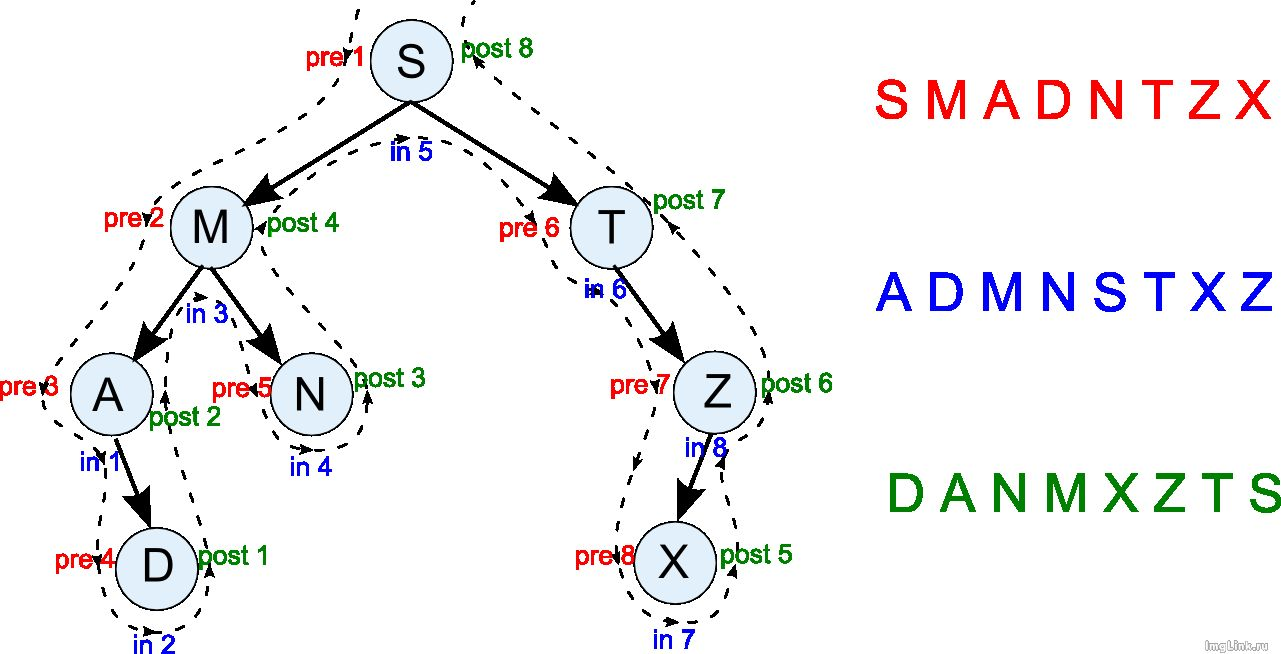

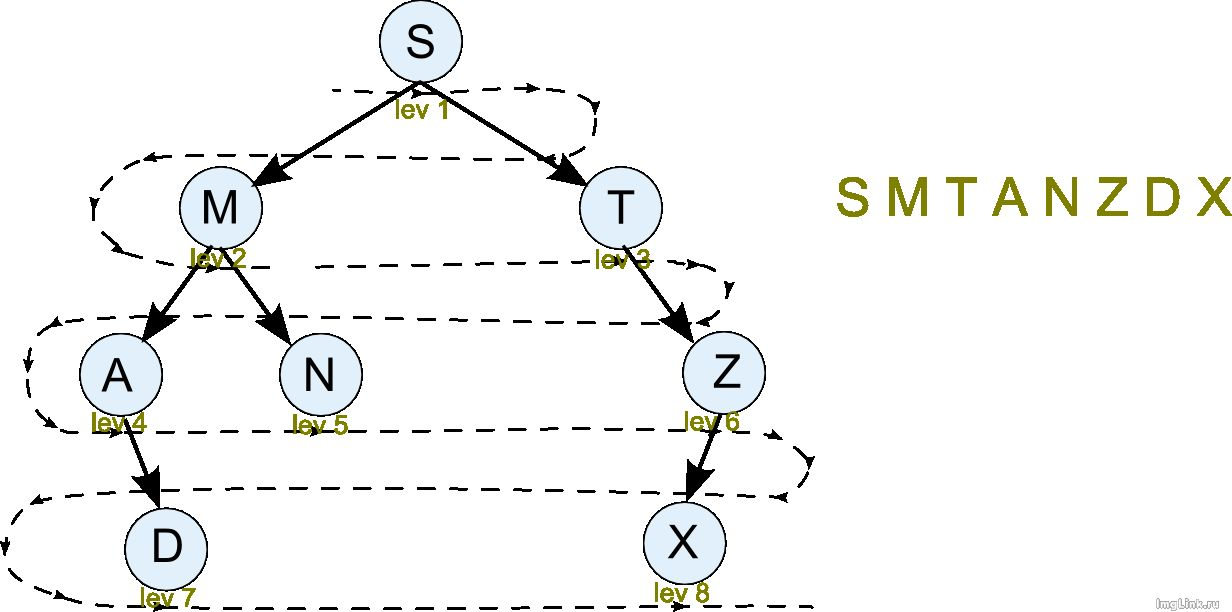

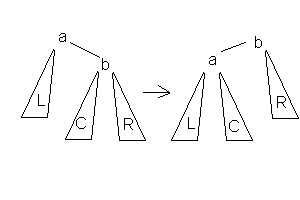 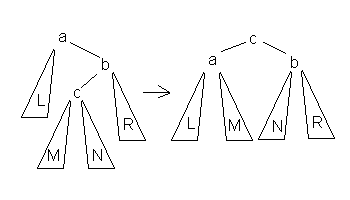

Зачем они нужны? К примеру, для баз данных и их индексов

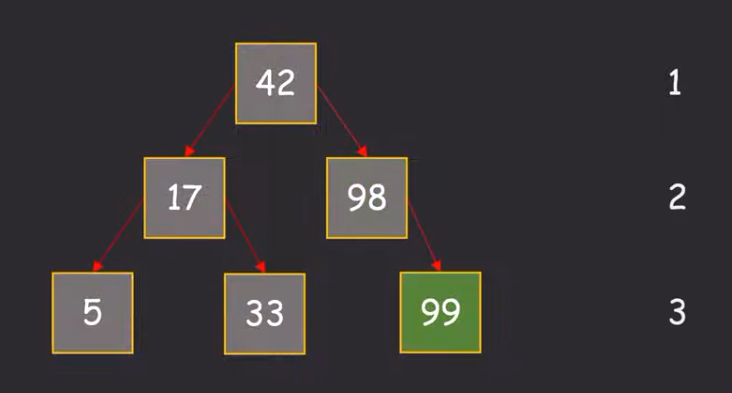

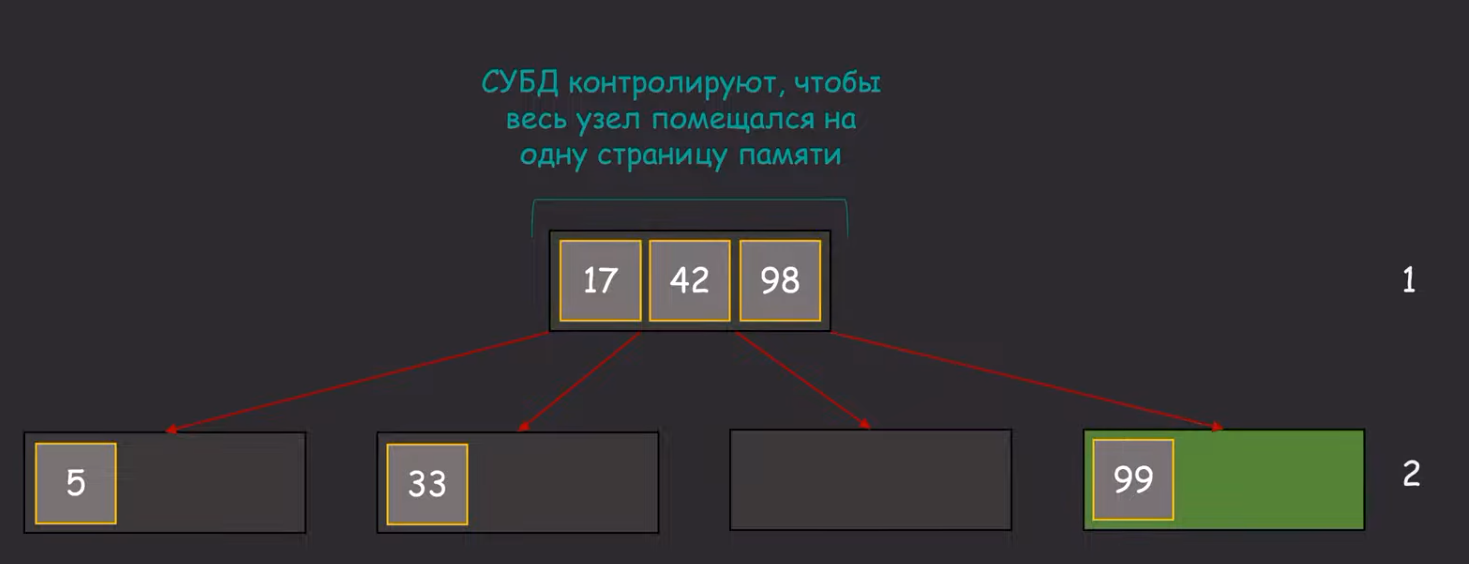

# Паттерны

Паттерн, в общем то, представляет из себя некую конструкцию, которую удобно переиспользовать из раза в раз на разных проектах (так, некоторые паттерны включены изначально в языках)

https://refactoring.guru/design-patterns/python

## Синглтон

In [ ]:
logger = None

def new_logger():
  path = "logs.txt"
  f = open(path, "w")
  return f

def create_logger():
  if logger:
    return logger
  logger = new_logger()
  return logger

In [ ]:
# cls.__new__ -> self
# self.__init__
# self.__del__

In [66]:
class Logger():
  def __new__(cls, *args, **kwargs):
    if not hasattr(cls, '_logger'):
        cls._logger = super(Logger, cls).__new__(cls, *args, **kwargs)
    # Возвращаем созданный (только что или ранее) объект.
    return cls._logger

  def __init__(self):
    pass

In [67]:
l = Logger()
l2 = Logger()
print(l is l2)

True


## Адаптер

In [68]:
class ForeignRunner():
  def foreign_run(self):
    return "gninnur"

  def other(self):
    print("i'm an alien")

class MyRunner():
  def run(self):
    return "running"

  def other(self):
    print("hi!")

class Adapter(MyRunner, ForeignRunner):
  def run(self):
    return self.foreign_run()[::-1]

In [69]:
mr = MyRunner()
mr.run()

'running'

In [70]:
fr = ForeignRunner()
fr.foreign_run()

'gninnur'

In [71]:
ar = Adapter()
ar.run()

'running'

In [72]:
Adapter().other()

hi!


## Наблюдатель

In [73]:
class Child():
  def __init__(self, name):
    self.name = name
    self.state = "calm"
    self.observers = []

  def do_smth_good(self):
    print("doing smth")
    self.state = "calm"
    for o in self.observers:
      o.check_state()

  def do_smth_bad(self):
    print("doing smth bad")
    self.state = "not calm"
    for o in self.observers:
      o.check_state()

class Parent():
  def __init__(self):
    self.observant = None

  def look_at(self, child):
    self.observant = child
    child.observers.append(self)

  def check_state(self):
    print(self.observant.state)
    if self.observant.state == "not calm":
      print(self.observant.name.upper())
      self.observant.state = "calm"


In [75]:
c = Child("Alice")
p1 = Parent()
p2 = Parent()
p1.look_at(c)
p2.look_at(c)

In [76]:
c.do_smth_bad()

doing smth bad
not calm
ALICE
calm


In [77]:
actions = [0,0,0,1,0,1,1,0]
for a in actions:
  if a == 0:
    c.do_smth_good()
  else:
    c.do_smth_bad()

doing smth
calm
calm
doing smth
calm
calm
doing smth
calm
calm
doing smth bad
not calm
ALICE
calm
doing smth
calm
calm
doing smth bad
not calm
ALICE
calm
doing smth bad
not calm
ALICE
calm
doing smth
calm
calm


# Мини домашка

## Задание 1

In [ ]:
#  elem1 - > elem2 -> elem3 -> elem4
#             ^                   |
#             |                   |
#              -------------------

# 1 цикл (шаг 1)
# elem1 elem2 elem3 elem4 elem2 elem3 ...
# 2 цикл (шаг 2)
# elem2 elem4 elem3

Хотим найти цикл в односвязном списке; если он есть - возвращаем True, если нет - False
При этом нам нельзя сохранять список уже посещенных нод, хотим сделать проверку в формате, который обсуждали на лекции (идти с разным шагом)

In [78]:
def find_cycle(node):
  pass

In [79]:
ll_1 = LinkedList(0)
ll_2 = LinkedList(1)
ll_3 = LinkedList(2)
ll_4 = LinkedList(3)

ll_1.bind_next(ll_2)
ll_2.bind_next(ll_3)
ll_3.bind_next(ll_4)

assert find_cycle(ll_1) == False

ll_4.bind_next(ll_2)

assert find_cycle(ll_1) == True

AssertionError: 

## Задание 2

Напишите класс ConnectToDB так, чтобы при передаче уже однажды переданных параметров возвращался созданный ранее экземпляр класса, при новых - новый

In [ ]:
class ConnectToDB():
  connections = {}

  def __new__(cls, *args, **kwargs):
    pass

  def __init__(self, address=""):
    self.address = address

In [ ]:
c1 = ConnectToDB(address="addr1")
c2 = ConnectToDB(address="addr1")
c3 = ConnectToDB(address="addr2")
assert c1 is c2
assert c1 is not c3